In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "lead1.0-small",
    "lead1.0-small.csv"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

NORMALIZED_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "normalized_dataset"
)

os.makedirs(MODEL_DIR, exist_ok=True)
if not os.path.exists(NORMALIZED_DIR):
    os.makedirs(NORMALIZED_DIR)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Model directory:", MODEL_DIR)
print("Normalized dataset path:", NORMALIZED_DIR)

Project root: d:\Machine Learning\projects\enegy consumption anamoly detection
Dataset: d:\Machine Learning\projects\enegy consumption anamoly detection\dataset\lead1.0-small\lead1.0-small.csv
Model directory: d:\Machine Learning\projects\enegy consumption anamoly detection\models
Normalized dataset path: d:\Machine Learning\projects\enegy consumption anamoly detection\dataset\normalized_dataset


In [3]:
df = pd.read_csv(DATA_PATH)

df.head()

,building_id,timestamp,meter_reading,anomaly
0,1,2016-01-01 00:00:00,NaN,0
1,32,2016-01-01 00:00:00,NaN,0
2,41,2016-01-01 00:00:00,NaN,0
3,55,2016-01-01 00:00:00,NaN,0
4,69,2016-01-01 00:00:00,NaN,0


In [4]:
df.isnull().sum()

building_id           0
timestamp             0
meter_reading    107653
anomaly               0
dtype: int64

In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (1749494, 4)


In [6]:
df.anomaly.value_counts()

anomaly
0    1712198
1      37296
Name: count, dtype: int64

In [7]:
df['timeStamp'] = pd.to_datetime(df['timestamp'])

In [8]:
df = df.sort_values("timeStamp").reset_index(drop=True)

In [9]:
building_count = df["building_id"].nunique()

start_time = df["timeStamp"].iloc[0]
end_time = df["timeStamp"].iloc[-1]

print("Building Count:", building_count)
print("Start Time:", start_time)
print("End Time:", end_time)

Building Count: 200
Start Time: 2016-01-01 00:00:00
End Time: 2016-12-31 23:00:00


In [10]:
df = df.drop('timestamp', axis=1)

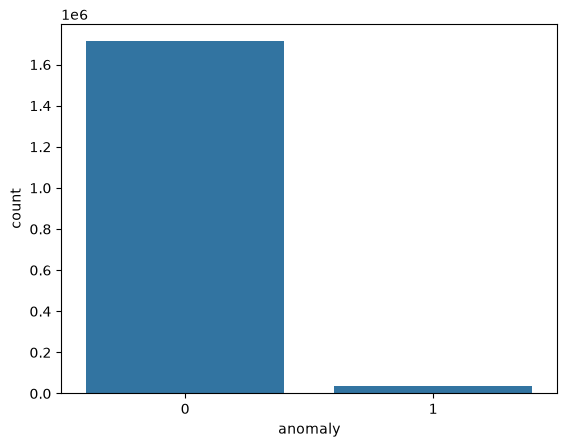

In [11]:
sns.countplot(x='anomaly', data=df)
plt.xlabel('anomaly')
plt.ylabel('count')
plt.show()

In [12]:
df['hour'] = df['timeStamp'].dt.hour
df['day'] = df['timeStamp'].dt.day_name()
df['month'] = df['timeStamp'].dt.month

In [13]:
df.head()

,building_id,meter_reading,anomaly,timeStamp,hour,day,month
0,1,NaN,0,2016-01-01,0,Friday,1
1,973,NaN,0,2016-01-01,0,Friday,1
2,974,NaN,0,2016-01-01,0,Friday,1
3,975,NaN,0,2016-01-01,0,Friday,1
4,977,NaN,0,2016-01-01,0,Friday,1


In [14]:
print(np.max(df.hour))
print(np.min(df.hour))

23
0


In [15]:
df['meter_reading'] = df['meter_reading'].ffill().bfill()

In [16]:
df['meter_reading'].isna().sum()

np.int64(0)

In [17]:
df.isnull().sum()

building_id      0
meter_reading    0
anomaly          0
timeStamp        0
hour             0
day              0
month            0
dtype: int64

In [18]:
df.anomaly.value_counts()

anomaly
0    1712198
1      37296
Name: count, dtype: int64

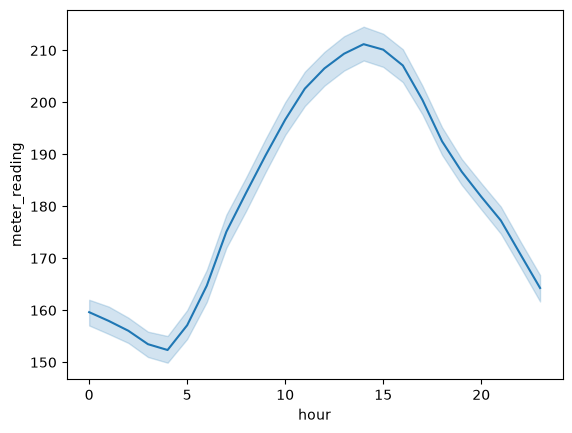

In [19]:
sns.lineplot(x='hour', y='meter_reading', data=df)
plt.xlabel('hour')
plt.ylabel('meter_reading')
plt.show()

Text(0, 0.5, 'meter_reading')

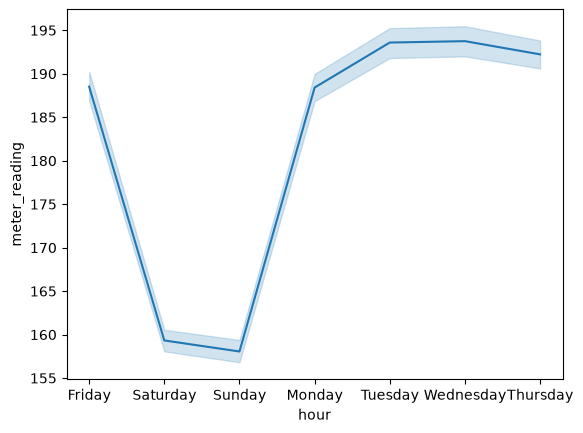

In [20]:
sns.lineplot(x='day', y='meter_reading', data=df)
plt.xlabel('hour')
plt.ylabel('meter_reading')

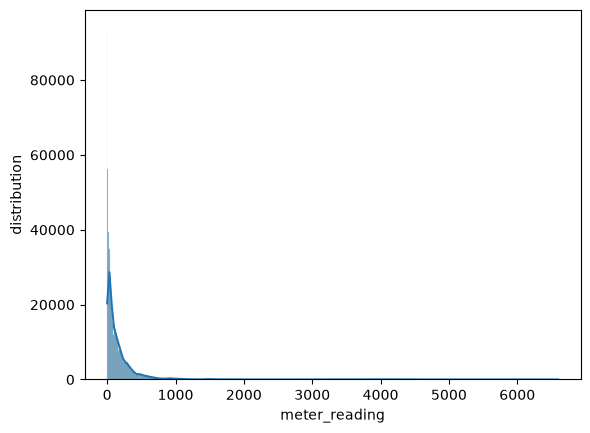

In [21]:
sns.histplot(df['meter_reading'], kde=True)
plt.xlabel('meter_reading')
plt.ylabel('distribution')
plt.show()

In [22]:
Building_grp = df.groupby('building_id')['meter_reading'].agg(['max', 'min', 'sum', 'mean']).reset_index()

In [23]:
Building_grp.head()

,building_id,max,min,sum,mean
0,1,934.50,0.08,1157171.769,131.736312
1,32,774.00,1.00,1073831.025,122.248523
2,41,778.00,1.00,867839.673,98.797777
3,55,774.00,1.00,720174.133,81.987037
4,69,814.03,0.08,702869.426,80.017011


In [24]:
print("max-max:", Building_grp.loc[Building_grp['max'].idxmax()])
print("max-min:", Building_grp.loc[Building_grp['max'].idxmin()])
print("min-max:", Building_grp.loc[Building_grp['max'].idxmax()])
print("min-min:", Building_grp.loc[Building_grp['min'].idxmin()])

max-max: building_id    8.010000e+02
max            6.596890e+03
min            1.000000e+00
sum            4.077398e+07
mean           4.643432e+03
Name: 82, dtype: float64
max-min: building_id     1353.000000
max               16.250000
min                1.350000
sum            52482.926000
mean               7.024886
Name: 199, dtype: float64
min-max: building_id    8.010000e+02
max            6.596890e+03
min            1.000000e+00
sum            4.077398e+07
mean           4.643432e+03
Name: 82, dtype: float64
min-min: building_id      312.000000
max             1009.360000
min                0.000000
sum            61143.840000
mean               6.962405
Name: 46, dtype: float64


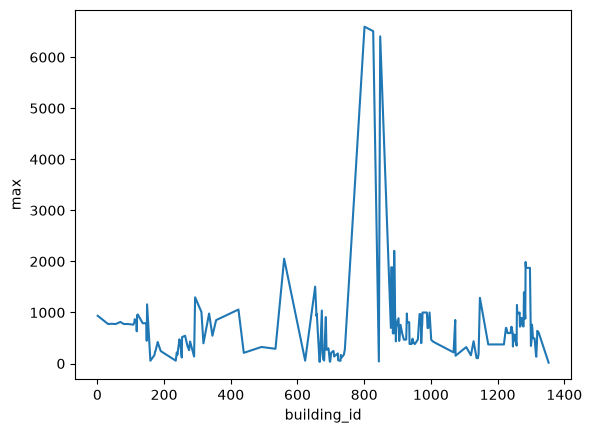

In [25]:
plt.plot('building_id', 'max', data=Building_grp)
plt.xlabel('building_id')
plt.ylabel('max')
plt.show()

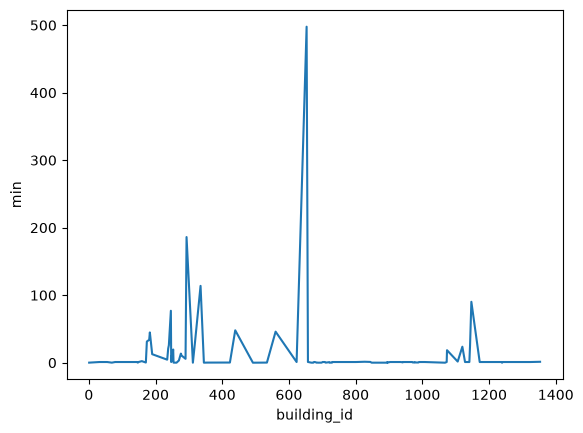

In [26]:
plt.plot('building_id', 'min', data=Building_grp)
plt.xlabel('building_id')
plt.ylabel('min')
plt.show()

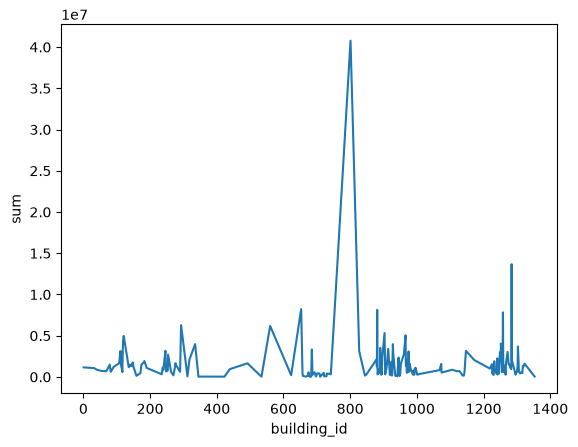

In [27]:
plt.plot('building_id', 'sum', data=Building_grp)
plt.xlabel('building_id')
plt.ylabel('sum')
plt.show()

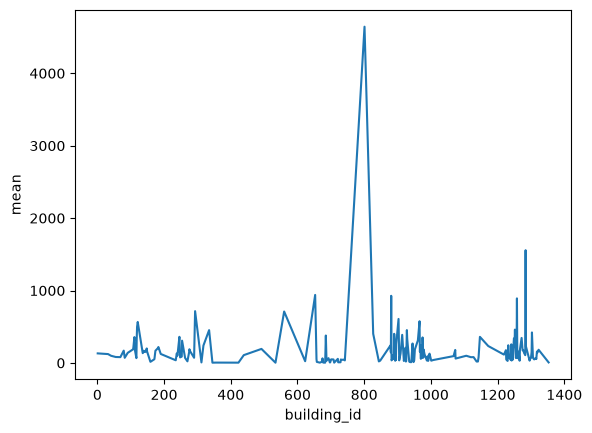

In [28]:
plt.plot('building_id', 'mean', data=Building_grp)
plt.xlabel('building_id')
plt.ylabel('mean')
plt.show()

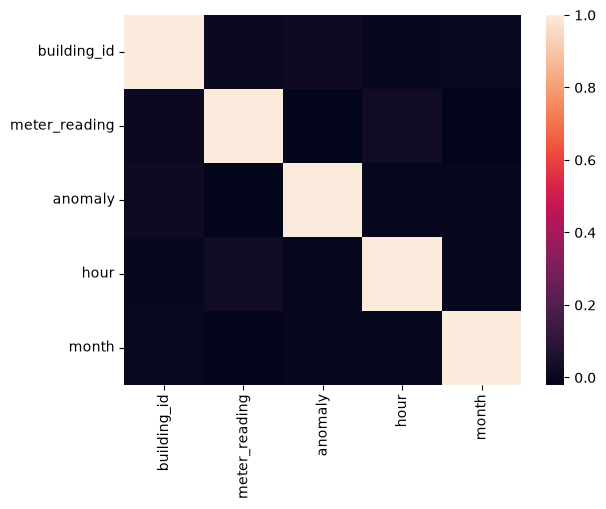

In [29]:
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.show()

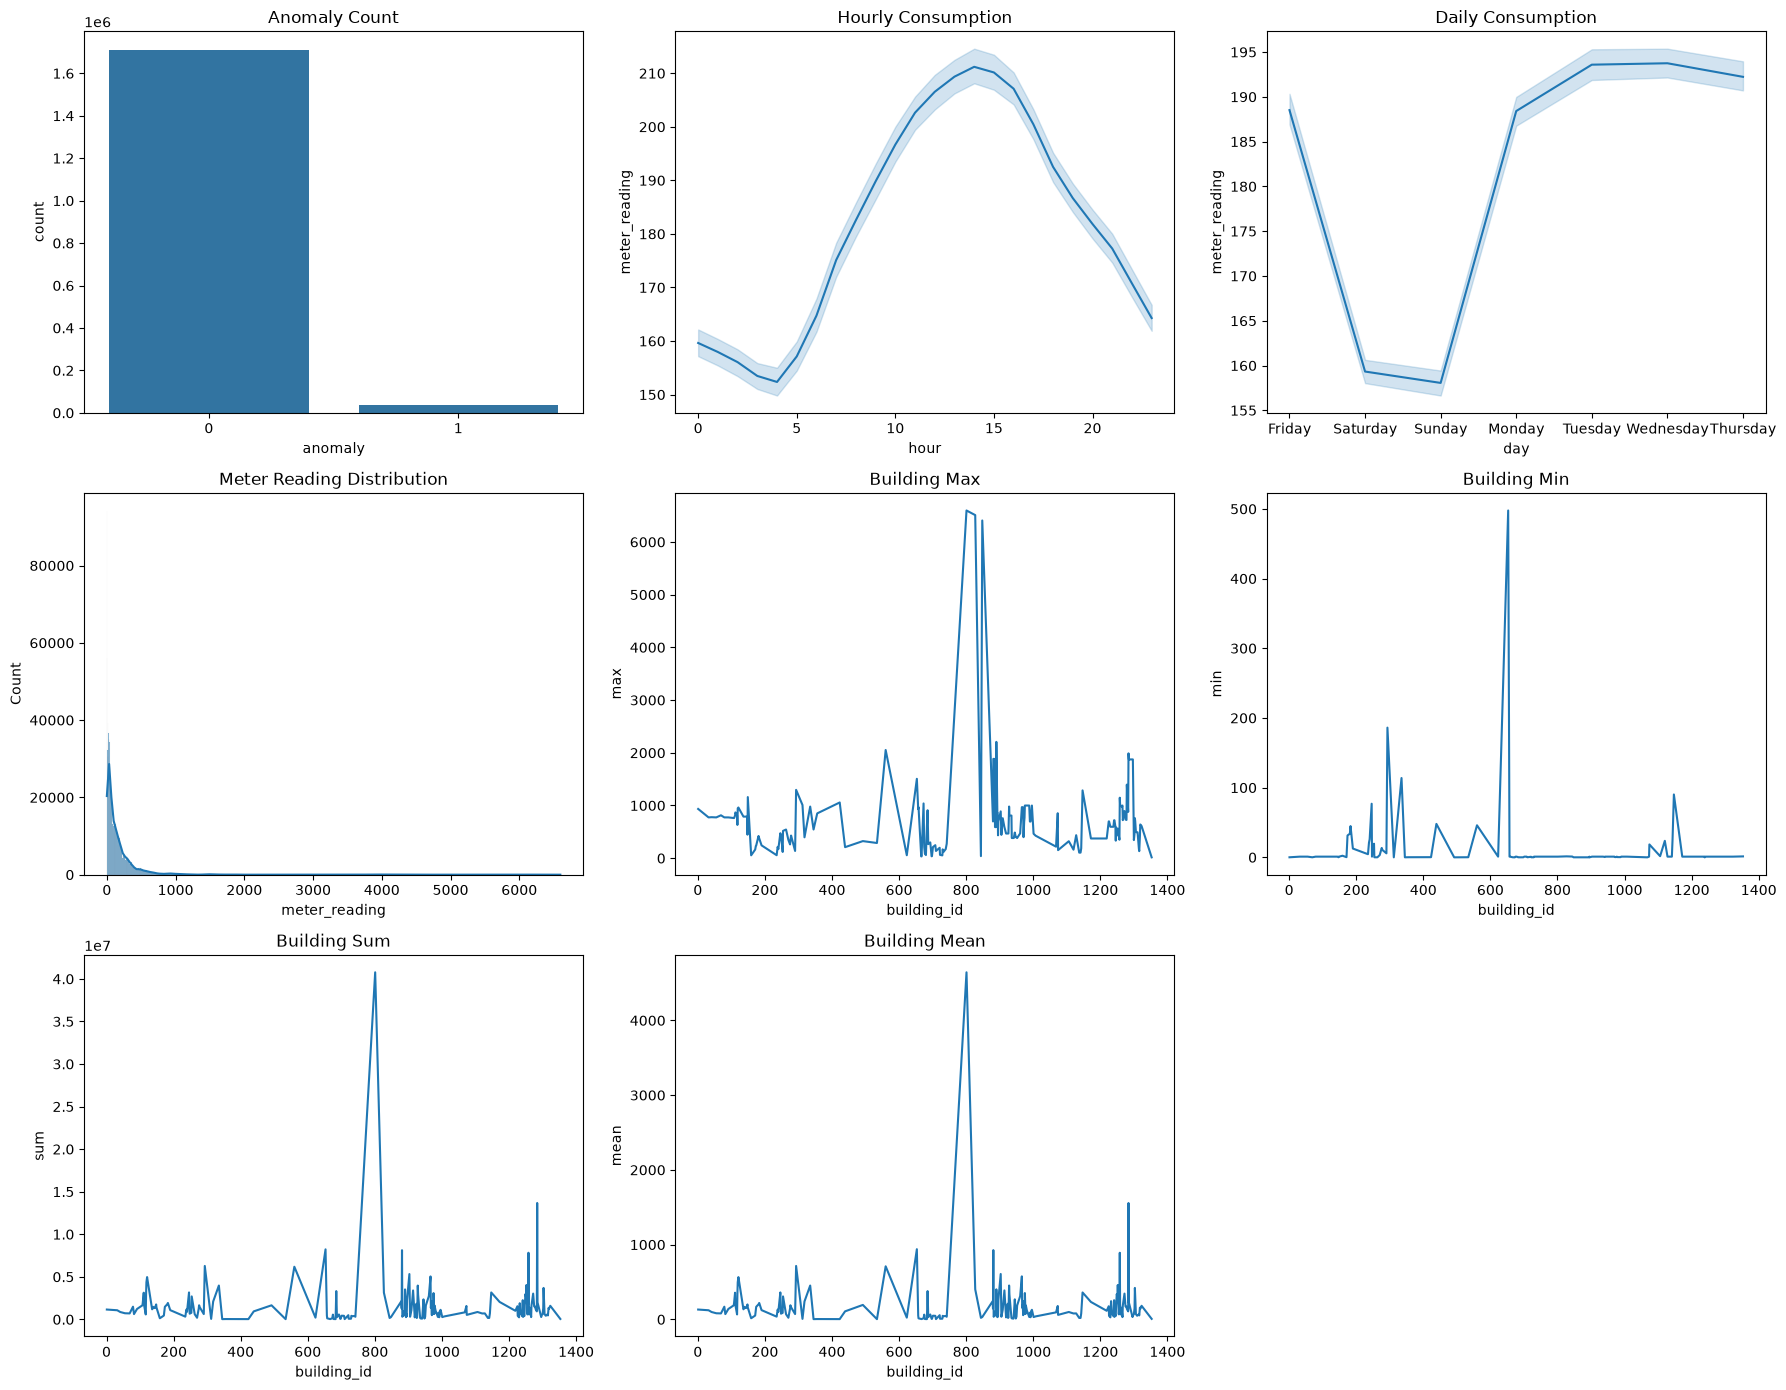

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.countplot(x='anomaly', data=df, ax=axes[0, 0])
axes[0, 0].set_title("Anomaly Count")
axes[0, 0].set_xlabel("anomaly")
axes[0, 0].set_ylabel("count")

sns.lineplot(x='hour', y='meter_reading', data=df, ax=axes[0, 1])
axes[0, 1].set_title("Hourly Consumption")

sns.lineplot(x='day', y='meter_reading', data=df, ax=axes[0, 2])
axes[0, 2].set_title("Daily Consumption")
axes[0, 2].set_xlabel("day")

sns.histplot(df['meter_reading'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Meter Reading Distribution")

sns.lineplot(x='building_id', y='max', data=Building_grp, ax=axes[1, 1])
axes[1, 1].set_title("Building Max")

sns.lineplot(x='building_id', y='min', data=Building_grp, ax=axes[1, 2])
axes[1, 2].set_title("Building Min")

sns.lineplot(x='building_id', y='sum', data=Building_grp, ax=axes[2, 0])
axes[2, 0].set_title("Building Sum")

sns.lineplot(x='building_id', y='mean', data=Building_grp, ax=axes[2, 1])
axes[2, 1].set_title("Building Mean")

axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

In [31]:
zero_readings = df[df['meter_reading'] == 0]
print(zero_readings['anomaly'].value_counts())

b801 = df[df['building_id'] == 801]
print(b801['anomaly'].value_counts(normalize=True))

b312 = df[df['building_id'] == 312].sort_values('timeStamp')
print(b312[b312['meter_reading'] == 0].head(10))

anomaly
0    25
Name: count, dtype: int64
anomaly
0    0.976882
1    0.023118
Name: proportion, dtype: float64
        building_id  meter_reading  anomaly           timeStamp  hour  \
837999          312            0.0        0 2016-06-24 07:00:00     7   
842802          312            0.0        0 2016-06-25 07:00:00     7   
847600          312            0.0        0 2016-06-26 07:00:00     7   
852393          312            0.0        0 2016-06-27 07:00:00     7   
857194          312            0.0        0 2016-06-28 07:00:00     7   
859590          312            0.0        0 2016-06-28 19:00:00    19   
861981          312            0.0        0 2016-06-29 07:00:00     7   

              day  month  
837999     Friday      6  
842802   Saturday      6  
847600     Sunday      6  
852393     Monday      6  
857194    Tuesday      6  
859590    Tuesday      6  
861981  Wednesday      6  


In [32]:
Building_grp = df.groupby('building_id')

In [33]:
buildings = (np.unique(df['building_id']))

In [34]:
print(buildings)

[   1   32   41   55   69   79   82   91  107  108  111  112  117  118
  119  121  136  137  139  141  144  147  148  149  159  171  173  174
  181  183  190  235  238  240  246  247  248  253  254  263  270  275
  276  278  290  293  312  318  335  345  356  423  439  492  534  560
  623  653  657  658  666  667  673  675  677  680  683  685  687  693
  697  698  701  708  710  721  722  729  730  732  739  742  801  827
  844  848  879  880  881  882  884  886  887  889  890  892  893  894
  895  896  903  905  909  914  919  922  924  925  926  928  929  931
  935  936  941  942  945  948  950  952  961  966  967  968  969  970
  971  973  974  975  977  978  981  988  990  992  994  996 1001 1007
 1068 1073 1074 1106 1120 1128 1137 1141 1143 1147 1172 1219 1225 1226
 1230 1232 1234 1238 1239 1241 1242 1245 1246 1247 1249 1251 1252 1253
 1255 1257 1258 1259 1260 1261 1264 1266 1267 1272 1275 1278 1279 1283
 1284 1285 1296 1297 1300 1302 1303 1304 1306 1309 1310 1311 1315 1316
 1318 

In [35]:
for i in buildings:
    meter_readings = df[df['building_id'] == i]
    print("buiding id", i, "no of meter readings", len(meter_readings))

buiding id 1 no of meter readings 8784
buiding id 32 no of meter readings 8784
buiding id 41 no of meter readings 8784
buiding id 55 no of meter readings 8784
buiding id 69 no of meter readings 8784
buiding id 79 no of meter readings 8784
buiding id 82 no of meter readings 8784
buiding id 91 no of meter readings 8784
buiding id 107 no of meter readings 8784
buiding id 108 no of meter readings 8784
buiding id 111 no of meter readings 8784
buiding id 112 no of meter readings 8784
buiding id 117 no of meter readings 8784
buiding id 118 no of meter readings 8784
buiding id 119 no of meter readings 8784
buiding id 121 no of meter readings 8784
buiding id 136 no of meter readings 8784
buiding id 137 no of meter readings 8784
buiding id 139 no of meter readings 8784
buiding id 141 no of meter readings 8784
buiding id 144 no of meter readings 8784
buiding id 147 no of meter readings 8784
buiding id 148 no of meter readings 8784
buiding id 149 no of meter readings 8784
buiding id 159 no of mete

In [36]:
type(df['building_id'][0])

numpy.int64

In [37]:
df['meter_reading_scaled'] = 0.0

In [38]:
df.head()

,building_id,meter_reading,anomaly,timeStamp,hour,day,month,meter_reading_scaled
0,1,5.0,0,2016-01-01,0,Friday,1,0.0
1,973,5.0,0,2016-01-01,0,Friday,1,0.0
2,974,5.0,0,2016-01-01,0,Friday,1,0.0
3,975,5.0,0,2016-01-01,0,Friday,1,0.0
4,977,5.0,0,2016-01-01,0,Friday,1,0.0


In [39]:
scalers = {}

for building_id, group in df.groupby('building_id'):
    scaler = MinMaxScaler()

    normal_data = group.loc[group['anomaly'] == 0, 'meter_reading'].values.reshape(-1, 1)
    scaler.fit(normal_data)

    df.loc[df['building_id'] == building_id, 'meter_reading_scaled'] =  scaler.transform(group['meter_reading'].values.reshape(-1, 1)).flatten()

    scalers[building_id] = scaler

print("Normalization done!")
print(f"Total scalers saved: {len(scalers)}")  # ✅ must print 200
print(df['meter_reading_scaled'].min(), df['meter_reading_scaled'].max())

Normalization done!
Total scalers saved: 200
-1.2250701065619742 4.110101311084625


In [40]:
with open('D:\\Machine Learning\\projects\\enegy consumption anamoly detection\\models\\scaler.pkl', 'wb') as f:
    joblib.dump(scalers, f)

In [41]:
scaler

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[16.25]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[1.35]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[14.9]
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.09]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,7317
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](1,)",[0.07]


In [42]:
print(scaler)

MinMaxScaler()


In [43]:
for bid in [801, 1353, 312]:
    subset = df[df['building_id'] == bid]['meter_reading_scaled']
    print(f"Building {bid} → min: {subset.min():.3f}, max: {subset.max():.3f}, mean: {subset.mean():.3f}")

Building 801 → min: 0.000, max: 1.000, mean: 0.704
Building 1353 → min: 0.000, max: 1.000, mean: 0.381
Building 312 → min: 0.000, max: 1.000, mean: 0.007
